In [10]:
import treecorr
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import fitsio

# Load Catalog

In [11]:
datadir_root = '/scratch/network/jm8767'
datadir = os.path.join(datadir_root, 'y3kp_cats')
desi_version = 'kibo'
datadir_desi = os.path.join(datadir_root, f'desi/spectro/redux/{desi_version}/zcatalog/v1')
#outdir = os.path.join(datadir_root, 'cl-lens')
#outfile = os.path.join(outdir, f'des_y3_v0.50_v2026-03-12_{desi_version}.hdf5') 
infile_desi = os.path.join(datadir_desi, f'zall-tilecumulative-{desi_version}.fits')

In [12]:
fits_file = infile_desi

In [13]:
cols_to_load = ['TARGET_RA', 'TARGET_DEC', 'SHAPE_E1', 'SHAPE_E2', 'Z', 'ZWARN'] 

# 2. Read only those columns from the 70 million rows
data = fitsio.read(fits_file, ext=1, columns=cols_to_load)

# 3. Optional but recommended: Filter out bad data
# Only keep galaxies with a solid redshift measurement (ZWARN == 0) 
# and perhaps apply a specific redshift cut for your cosmic shear bin.
good_gals = (data['ZWARN'] == 0) & (data['Z'] > 0.2) & (data['Z'] < 1.0)
data_clean = data[good_gals]

ra = data_clean['TARGET_RA']
dec = data_clean['TARGET_DEC']
g1 = data_clean['SHAPE_E1'] 
g2 = data_clean['SHAPE_E2']

# TreeCorr Calculations

https://rmjarvis.github.io/TreeCorr/_build/html/gg.html

In [14]:
cat = treecorr.Catalog(ra=ra, dec=dec, g1=g1, g2=g2, ra_units='degrees', dec_units='degrees')
gg = treecorr.GGCorrelation(min_sep=1.0, max_sep=100.0, nbins=20, sep_units='arcmin')
gg.process(cat)

r = np.exp(gg.meanlogr)

# correlation functions
#xi_+
xip = gg.xip
# # xi_-
xim = gg.xim

#calculate variance
sig_xip = np.sqrt(gg.varxip)
sig_xim = np.sqrt(gg.varxim)

# Plot

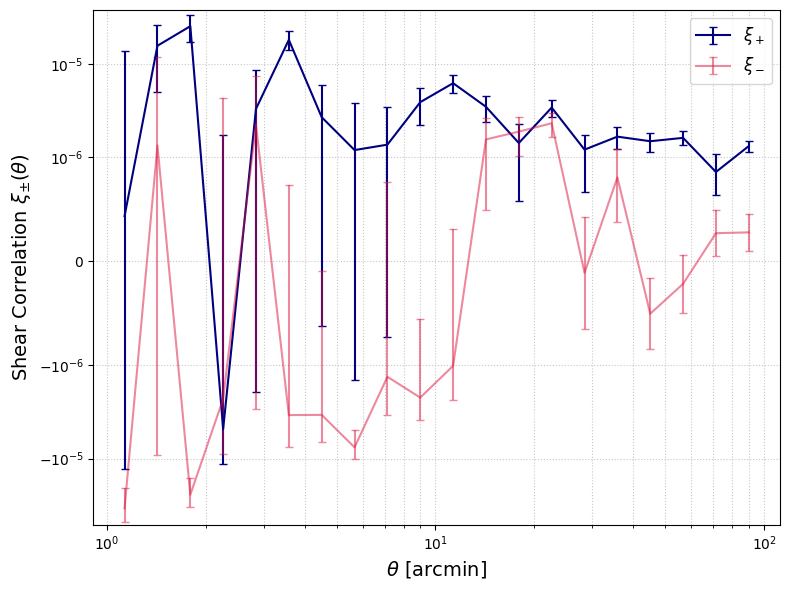

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(r, xip, yerr=sig_xip, label=r'$\xi_+$', color='navy', capsize=3)
ax.errorbar(r, xim, yerr=sig_xim, label=r'$\xi_-$', color='crimson', capsize=3, alpha = 0.5)

ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=1e-6) 
ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'Shear Correlation $\xi_{\pm}(\theta)$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()